<a href="https://colab.research.google.com/github/IanWills03/Programming-for-Data-Analysis-CMet/blob/main/Programming_for_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Programming for data Anaylsis Assessment Submission
# Task 1: Data Selection and Handling


In [1]:
!pip install streamlit
!pip install --upgrade Streamlit
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.8 MB/s eta 0:00:00


This part establishes a connection between google colab and the main branch in my github repository

In [2]:
! git config --global user.name "IanWills03"
! git config --global user.email "ianwills003@gmail.com"
username = "IanWills03"
repo = "Programming-for-Data-Analysis-CMet"
! git clone https://github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-CMet'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 31 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 3.29 MiB | 3.15 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [3]:
import os
%cd /content/Programming-for-Data-Analysis-CMet

/content/Programming-for-Data-Analysis-CMet


This part merges the four csv files into one csv file

In [4]:
beijing_air_files = glob.glob("*.csv")
all_cities_data = []

for file_name in beijing_air_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("combined_air_pollution_dataset.csv")

print(f"SUCCESS: Combined {len(beijing_air_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: combined_air_pollution_dataset.csv")


Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: combined_air_pollution_dataset.csv


In [5]:
df = pd.read_csv("combined_air_pollution_dataset.csv")
df

,Unnamed: 0,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,140251,35060,2017,2,28,19,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling
140252,140252,35061,2017,2,28,20,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1,Dingling
140253,140253,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling
140254,140254,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling


# Task 2: Exploratory Data Analysis (EDA)

**Task 2.1: Data Understanding**

The dataset includes both air pollutant variables (PM2.5, PM10, SO2, NO2, CO, O3) and meteorological variables (temperature, pressure, wind speed, etc.), allowing analysis of environmental factors influencing air quality.

In [6]:
df = pd.read_csv("combined_air_pollution_dataset.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  140256 non-null  int64  
 1   No          140256 non-null  int64  
 2   year        140256 non-null  int64  
 3   month       140256 non-null  int64  
 4   day         140256 non-null  int64  
 5   hour        140256 non-null  int64  
 6   PM2.5       137128 non-null  float64
 7   PM10        137889 non-null  float64
 8   SO2         137376 non-null  float64
 9   NO2         135114 non-null  float64
 10  CO          132224 non-null  float64
 11  O3          136498 non-null  float64
 12  TEMP        140081 non-null  float64
 13  PRES        140083 non-null  float64
 14  DEWP        140079 non-null  float64
 15  RAIN        140087 non-null  float64
 16  wd          139577 non-null  object 
 17  WSPM        140108 non-null  float64
 18  station     140256 non-null  object 
dtypes:

,0
Unnamed: 0,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3128
PM10,2367
SO2,2880
NO2,5142


This creates a heat map of the missing data

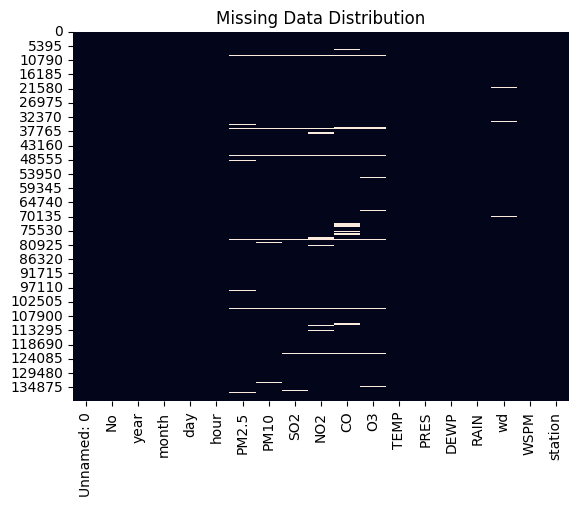

,Unnamed: 0,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000000,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000
mean,70127.500000,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524
std,40488.564015,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475
min,0.000000,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000
25%,35063.750000,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000
50%,70127.500000,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000
75%,105191.250000,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000
max,140255.000000,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000


In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Distribution")
plt.show()
df.describe()

The heatmap shows that missing values are present across several pollutant variables such as CO, NO2, and PM2.5. These missing values are scattered rather than concentrated, suggesting they are likely due to temporary sensor failures rather than systematic data loss

**Task 2.2: Data Preprocessing**

This section of the project was performed to clean and prepare the dataset for future analysis. This involved using both numerical and non-numerical interpolation tehcniques to deal with missing values, removing data duplicates and implementing feature engineering, such as datetime componenets and Air Quality Index levels.

A bar chart of the wind direction to see how much variation to determine whether the variable could be disregard. The verdict was im going to keep it as there is lots of variation.




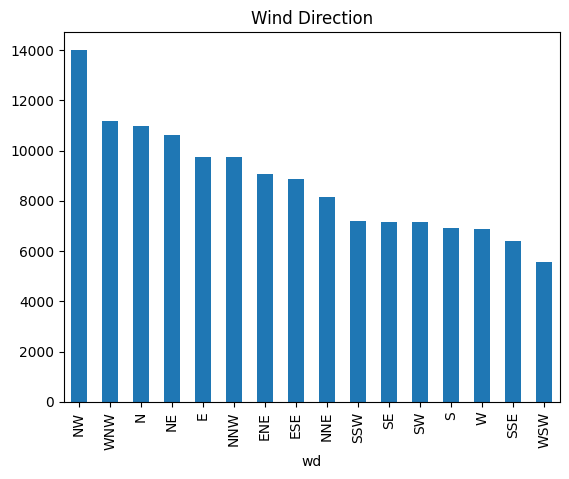

In [8]:
windDirection = df["wd"].value_counts()
windDirection.plot.bar()
plt.title("Wind Direction")
plt.show()

This part creates the "datetime" column, groups the data by station, year and month and then finally uses linear interpolation to handle numerical missing values and then ffill and bfill methods to replace non-numerical missing values.

In [9]:
df = pd.read_csv("combined_air_pollution_dataset.csv")

df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values(by=["station", "datetime"])

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols] = df.groupby(["station", "year", "month"])[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df["wd"] = df.groupby("station")["wd"].ffill().bfill()



*   Check to ensure that all missing values have been imputed



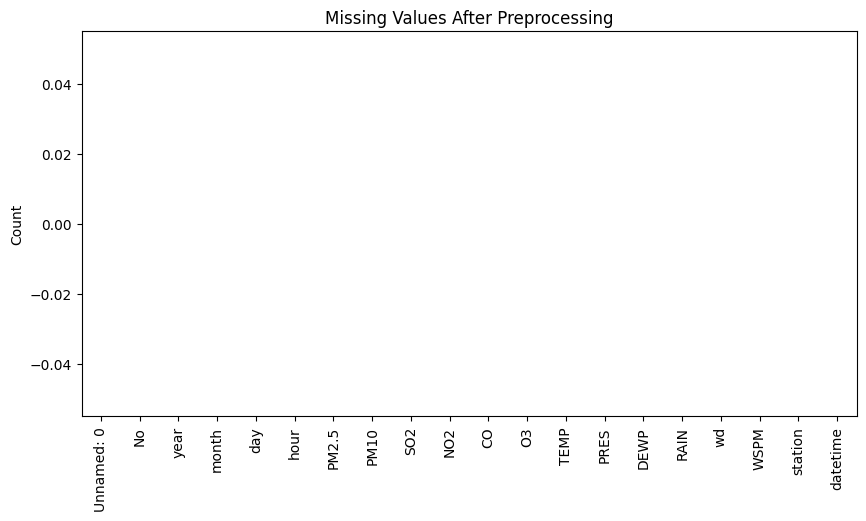

In [10]:
missing = df.isnull().sum()

missing.plot(kind="bar", figsize=(10,5))
plt.title("Missing Values After Preprocessing")
plt.ylabel("Count")
plt.show()

This barchart shows that there are no missing values left in the dataset after data preprocessing

Addings the following feature engineering categories:


*   Datetime components
*   Air Quality Index levels





In [11]:
df["month"] = df["datetime"].dt.month
df["day_of_week"] = df["datetime"].dt.day_name()
df["hour"] = df["datetime"].dt.hour

def aqi_level(pm25):
    if pm25 <= 12:
        return "Good"
    elif pm25 <= 35:
        return "Moderate"
    elif pm25 <= 55:
        return "Unhealthy for Sensitive"
    elif pm25 <= 150:
        return "Unhealthy"
    else:
        return "Hazardous"
    df["AQI_Level"].value_counts().plot(kind="bar")
    plt.title("AQI Level Distribution")
    plt.show()




*   Numerical data was imputed using the built in Pandas linear interpolation function, ensuring the values were estimated based on observations from the same station and similar year and month.
*  Non numerical data, particularly the wind direction (wd), interpolation was not applicable. This meant that the forward fill technique was preferred



**Task 2.3: Statistical/Computational Analysis & Visualisation**

2.3.1 Univariate Analysis

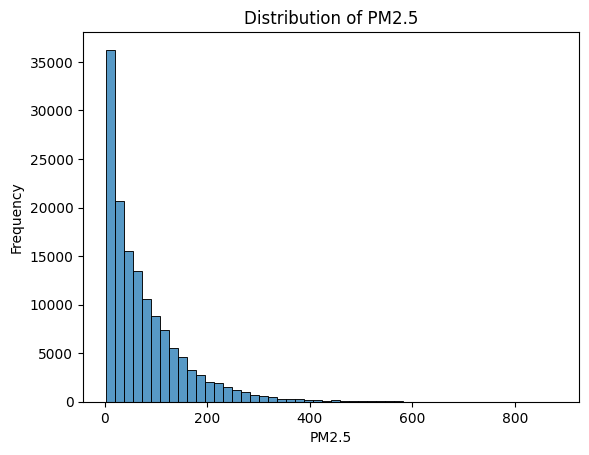

In [12]:
sns.histplot(df["PM2.5"], bins=50)
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

2.3.2 Bivariate Analysis

2.3.3 Multivariate Analysis